In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
def guassian_kernel(x,xi,tau):
    return np.exp((-np.sum(x-xi)**2)/(2*tau**2))

In [46]:
def lwr(x,X,y,tau):
    m=X.shape[0]
    weight=np.array([guassian_kernel(x,X[i],tau) for i in range(m)])
    W=np.diag(weight)
    X_t_W= X.T @ W
    theta=np.linalg.inv(X_t_W@X)@X_t_W@y
    return x @ theta

In [47]:
#load dataset
data=pd.read_csv('tips.csv')

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [49]:
X=data["total_bill"].values
y=data["tip"].values

In [50]:
print(X[:20])

[16.99 10.34 21.01 23.68 24.59 25.29  8.77 26.88 15.04 14.78 10.27 35.26
 15.42 18.43 14.83 21.58 10.33 16.29 16.97 20.65]


In [51]:
print(y[:20])

[1.01 1.66 3.5  3.31 3.61 4.71 2.   3.12 1.96 3.23 1.71 5.   1.57 3.
 3.02 3.92 1.67 3.71 3.5  3.35]


In [52]:
x_bias=np.c_[np.ones(X.shape),X]

In [53]:
print(x_bias[:20])

[[ 1.   16.99]
 [ 1.   10.34]
 [ 1.   21.01]
 [ 1.   23.68]
 [ 1.   24.59]
 [ 1.   25.29]
 [ 1.    8.77]
 [ 1.   26.88]
 [ 1.   15.04]
 [ 1.   14.78]
 [ 1.   10.27]
 [ 1.   35.26]
 [ 1.   15.42]
 [ 1.   18.43]
 [ 1.   14.83]
 [ 1.   21.58]
 [ 1.   10.33]
 [ 1.   16.29]
 [ 1.   16.97]
 [ 1.   20.65]]


In [54]:
x_test=np.linspace(X.min(),X.max(),100)
x_test_bias=np.c_[np.ones(x_test.shape),x_test]
tau=1

In [55]:
y_pred=np.array([lwr(xi,x_bias,y,tau) for xi in x_test_bias])

In [56]:
print(y_pred)

[ 0.99958986  1.01232284  1.04313566  1.08485258  1.08533593  1.13118869
  1.42330332  1.8131059   2.0724279   2.07336679  1.95690067  1.8708172
  1.83436643  1.82969863  1.83523952  1.84605766  1.87513029  1.91967648
  1.97153127  2.03029127  2.10498843  2.20163673  2.29932173  2.37597952
  2.43435902  2.48576064  2.54614026  2.63407173  2.74133144  2.83880347
  2.90943685  2.95034139  2.97477941  3.00713031  3.0591849   3.13531827
  3.23962     3.35385898  3.44312624  3.50205921  3.53750578  3.55062923
  3.54691236  3.55315776  3.61321089  3.73033764  3.81792853  3.80740126
  3.72830467  3.64456672  3.6157047   3.65342335  3.72197558  3.79654676
  3.86566979  3.91816473  3.952731    3.99233869  4.03578298  4.05552467
  4.03954529  4.01754143  4.07569684  4.22192436  4.41452477  4.62175102
  4.76555404  4.73326316  4.53693061  4.31284762  4.12938162  3.95941633
  3.76506031  3.83070981  4.23757372  4.58327796  4.72093013  4.64934036
  4.48745841  4.4727059   4.56266462  4.56414723  4.

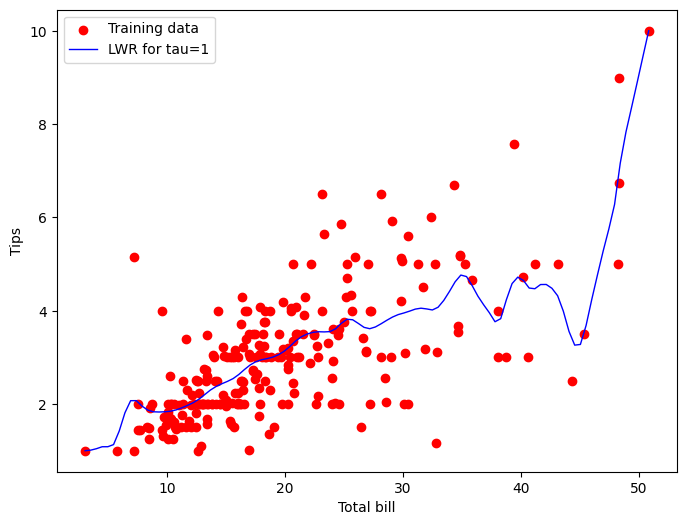

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(X,y,marker='o',label='Training data',color='red')
plt.plot(x_test,y_pred,color='blue',label='LWR for tau=1',linewidth=1)
plt.legend()
plt.xlabel('Total bill')
plt.ylabel('Tips')
plt.show()

In [60]:
#Custom dataset
np.random.seed(42)

X1=np.linspace(0,2*np.pi,100)
y1=np.sin(X1)+0.1*np.random.randn(100)

x_bias1= np.c_[np.ones(X1.shape),X1]

In [61]:
print(x_bias1[:10])

[[1.         0.        ]
 [1.         0.06346652]
 [1.         0.12693304]
 [1.         0.19039955]
 [1.         0.25386607]
 [1.         0.31733259]
 [1.         0.38079911]
 [1.         0.44426563]
 [1.         0.50773215]
 [1.         0.57119866]]


In [63]:
x_test1=np.linspace(0,2*np.pi,200)
x_test_bias1=np.c_[np.ones(x_test1.shape),x_test1]
tau=0.5
y_pred1=np.array([lwr(xi,x_bias1,y1,tau) for xi in x_test_bias1])

In [64]:
print(y_pred1[:20])

[0.10366716 0.12847148 0.15291197 0.17699166 0.20071383 0.22408202
 0.24709983 0.26977092 0.29209882 0.31408688 0.33573814 0.35705518
 0.37804006 0.39869421 0.41901827 0.43901203 0.45867436 0.47800307
 0.49699489 0.51564535]


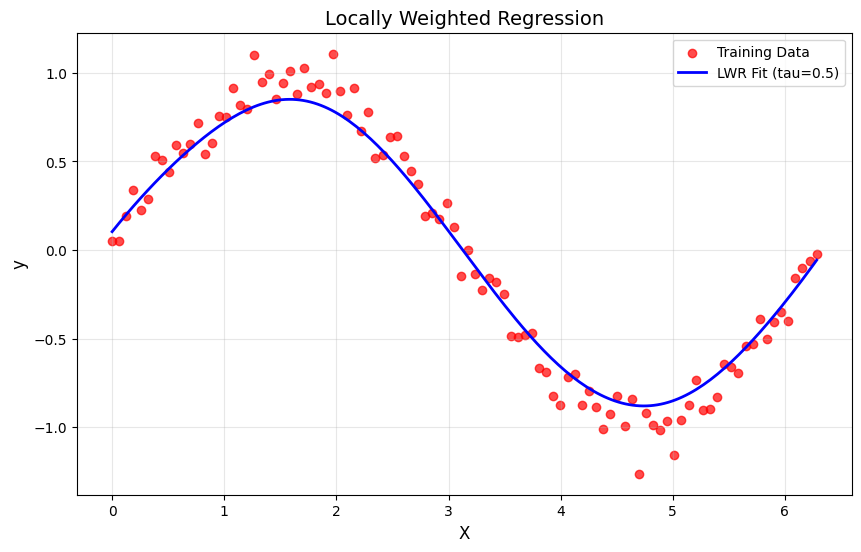

In [65]:
plt.figure(figsize=(10, 6))
plt.scatter(X1,y1,color='red', label='Training Data',alpha=0.7)
plt.plot(x_test1, y_pred1,color='blue',label=f'LWR Fit (tau={tau})',linewidth=2)
plt.xlabel('X',fontsize=12)
plt.ylabel('y',fontsize=12)
plt.title('Locally Weighted Regression',fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()